# Семинар 2. Ван-дер-Поль: что можно узнать из численного решения

На прошлой паре мы уже получили численное решение уравнения Ван-дер-Поля, построили $x(t)$ и фазовые траектории и увидели, что решения выходят на предельный цикл.

Сегодня останемся с той же системой, но попробуем извлечь из решения больше информации. Нас будут интересовать не только графики, но и конкретные величины: амплитуда, период, переходный процесс и их зависимость от $\mu$.

Рассматриваем
$$
x''-\mu(1-x^2)x'+x=0,\qquad \mu > 0,
$$
или, после замены $y=x'$,
$$
\begin{cases}
x'=y,\\
y'=\mu(1-x^2)y-x.
\end{cases}
$$

По ходу работы будут короткие вопросы. На некоторые из них нужно ответить **до запуска ячейки**.

Если в выводе вы приводите конкретное численное значение, оно должно быть получено в notebook вычислением, а не оценено по графику или вписано вручную.

## 0. Импорт библиотек

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

## 1. Что находится внутри результата `solve_ivp`

Для начала повторим уже знакомый расчёт:
$$
\mu=1,\qquad x(0)=0.1,\qquad y(0)=0.
$$

Перед запуском посмотрите на функцию `vdp` и ответьте:

1. Что лежит в `state`?
2. Что должна вернуть функция?
3. Сколько строк должно быть в `sol.y`?

In [2]:
def vdp(t, state, mu):
    x, y = state
    return [y, mu * (1 - x**2) * y - x]


mu = 1.0
t_eval = np.linspace(0, 60, 6001)

sol = solve_ivp(
    vdp,
    t_span=(0, 60),
    y0=[0.1, 0.0],
    t_eval=t_eval,
    args=(mu,),
    rtol=1e-8,
    atol=1e-10,
)

print("success:", sol.success)
print("sol.t.shape =", sol.t.shape)
print("sol.y.shape =", sol.y.shape)

success: True
sol.t.shape = (6001,)
sol.y.shape = (2, 6001)


### Разберёмся с индексами

Запустите следующую ячейку и объясните, что выдаёт каждая строка.

Обратите внимание на разницу между

- `sol.y[0]`,
- `sol.y[:, 0]`,
- `sol.y[:, -1]`.

In [3]:
x = sol.y[0]
y = sol.y[1]

print("Первые 5 моментов времени:", sol.t[:5])
print("Первые 5 значений x(t):", x[:5])
print("Начальное состояние:", sol.y[:, 0])
print("Конечное состояние:", sol.y[:, -1])

Первые 5 моментов времени: [0.   0.01 0.02 0.03 0.04]
Первые 5 значений x(t): [0.1        0.09999498 0.09997987 0.09995455 0.09991894]
Начальное состояние: [0.1 0. ]
Конечное состояние: [ 1.53011576 -0.76804887]


### Покажите преподавателю

Ответьте без дополнительного кода:

1. Какой `shape` у `sol.y`?
2. Что означают две координаты этого массива?
3. Как получить $y$ в последний момент времени?
4. Почему `sol.y[0, -1]` — число, а `sol.y[0]` — массив?

## 2. Отделяем переходный процесс

Первые колебания нам сейчас не очень интересны: решение ещё выходит на установившийся режим.

Для начала оставим только часть решения при $t\ge 20$.

Перед запуском: как вы думаете, что находится в `mask` — числа, индексы или логические значения?

In [4]:
mask = sol.t >= 20

print("type(mask) =", type(mask))
print("mask.shape =", mask.shape)
print("Первые элементы mask:", mask[:8])
print("Последние элементы mask:", mask[-8:])

t_ss = sol.t[mask]
x_ss = x[mask]
y_ss = y[mask]

print("Число точек после t=20:", len(t_ss))

type(mask) = <class 'numpy.ndarray'>
mask.shape = (6001,)
Первые элементы mask: [False False False False False False False False]
Последние элементы mask: [ True  True  True  True  True  True  True  True]
Число точек после t=20: 4001


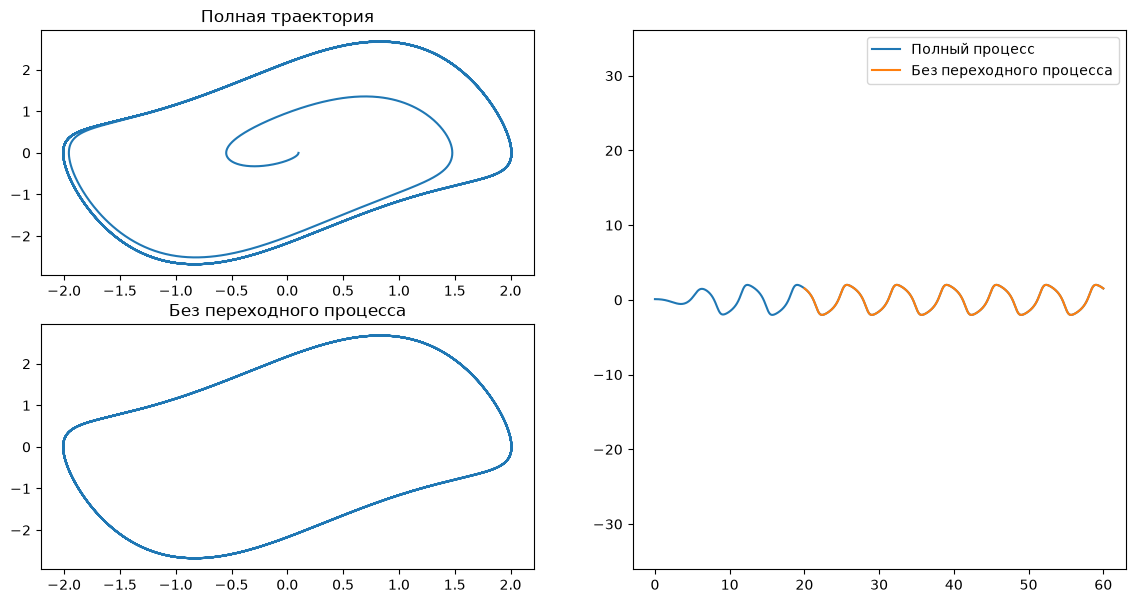

In [5]:
fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[:, 1])

ax1.plot(x, y)
ax2.plot(x_ss, y_ss)

ax3.plot(sol.t, x, label='Полный процесс')
ax3.plot(t_ss, x_ss, label='Без переходного процесса')

ax3.axis('equal')
ax3.legend(loc='upper right')

ax1.set_title('Полная траектория')
ax2.set_title('Без переходного процесса')
plt.show()

### Амплитуда

Для почти симметричного периодического сигнала оценим амплитуду так:
$$
A\approx\frac{\max x-\min x}{2}.
$$

После запуска вернитесь к предыдущей ячейке, замените `20` на `30` и посмотрите, насколько изменится результат.

Почему после окончания переходного процесса оценка амплитуды должна быть почти той же?

In [6]:
amplitude = (x_ss.max() - x_ss.min()) / 2
center = (x_ss.max() + x_ss.min()) / 2

print(f"amplitude ≈ {amplitude:.6f}")
print(f"center ≈ {center:.6f}")

amplitude ≈ 2.008619
center ≈ -0.000000


In [7]:
%pip install ipympl

Note: you may need to restart the kernel to use updated packages.


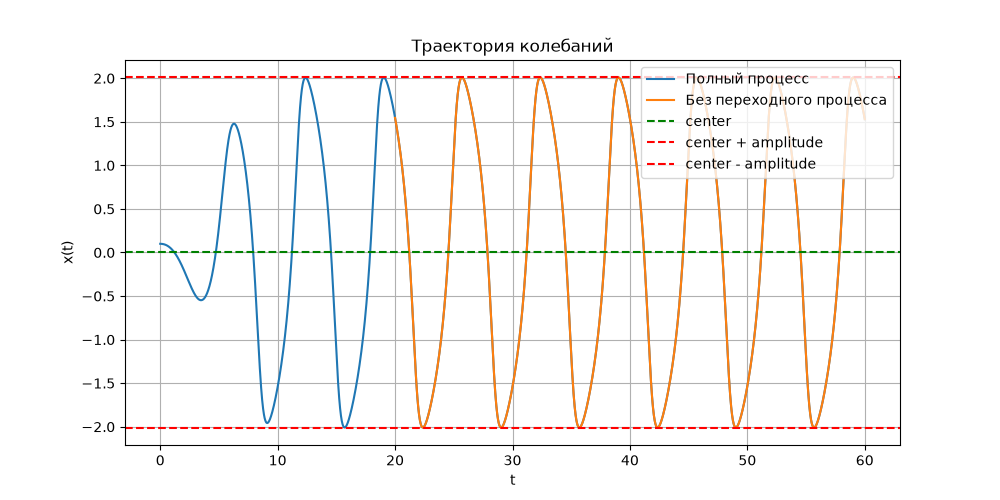

In [8]:
%matplotlib widget

plt.figure(figsize=(10, 5))

plt.plot(sol.t, x, label='Полный процесс')
plt.plot(t_ss, x_ss, label='Без переходного процесса')

plt.axhline(center, linestyle='--', label='center', color='green')
plt.axhline(center + amplitude, linestyle='--', label='center + amplitude', color='red')
plt.axhline(center - amplitude, linestyle='--', label='center - amplitude', color='red')

plt.legend(loc='upper right')
plt.title('Траектория колебаний')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid()
plt.show()

## 3. Оцениваем период

На графике период можно примерно увидеть глазами, но лучше получить его непосредственно из данных.

Найдём локальные максимумы $x(t)$. Функция `find_peaks` возвращает их **индексы**.

In [9]:
peaks, _ = find_peaks(x_ss, prominence=0.5)

peak_times = t_ss[peaks]
peak_values = x_ss[peaks]

print("Последние времена максимумов:")
print(peak_times[-6:])

print("\nПоследние значения максимумов:")
print(peak_values[-6:])

Последние времена максимумов:
[25.7  32.36 39.03 45.69 52.35]

Последние значения максимумов:
[2.00861913 2.00861387 2.00860158 2.00861888 2.00861454]


Перед запуском следующей ячейки подумайте:

1. Что вернёт `np.diff(peak_times)`?
2. Если решение уже вышло на цикл, что должно происходить с этими разностями?

In [10]:
periods = np.diff(peak_times)

print("Последние оценки периода:")
print(periods[-5:])

period = periods[-5:].mean()
period_std = periods[-5:].std()

print(f"Средний период T ≈ {period:.6f}")
print(f"Разброс последних периодов ≈ {period_std:.2e}")

Последние оценки периода:
[6.66 6.67 6.66 6.66]
Средний период T ≈ 6.662500
Разброс последних периодов ≈ 4.33e-03


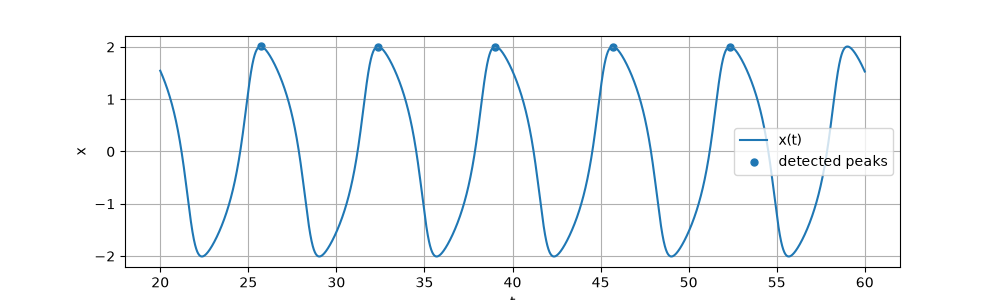

In [11]:
plt.figure(figsize=(10, 3))
plt.plot(t_ss, x_ss, label="x(t)")
plt.scatter(peak_times, peak_values, s=25, label="detected peaks")
plt.xlabel("t")
plt.ylabel("x")
plt.grid()
plt.legend()
plt.show()

### Покажите преподавателю

Покажите найденные $A$ и $T$ и ответьте:

1. Почему период лучше оценивать по нескольким последним максимумам, а не по первым двум?
2. Что изменится, если сделать сетку `t_eval` в несколько раз плотнее?
3. Изменится ли от этого само решение дифференциального уравнения?

## 4. Откуда берётся устойчивый цикл

Рассмотрим
$$
E(x,y)=\frac{x^2+y^2}{2}.
$$

При $\mu=0$ это энергия гармонического осциллятора. При $\mu > 0$ она уже не сохраняется.

Найдём $\dot E$ символически.

In [12]:
xs, ys, mus = sp.symbols("x y mu", real=True)

E = (xs**2 + ys**2) / 2

x_dot = ys
y_dot = mus * (1 - xs**2) * ys - xs

E_dot = sp.diff(E, xs) * x_dot + sp.diff(E, ys) * y_dot
sp.factor(E_dot)

-mu*y**2*(x - 1)*(x + 1)

Посмотрите на полученную формулу и **до следующего графика** ответьте:

- какой знак у $\dot E$, если $|x|<1$?
- какой знак у $\dot E$, если $|x|>1$?
- что это должно означать для маленьких и больших колебаний?

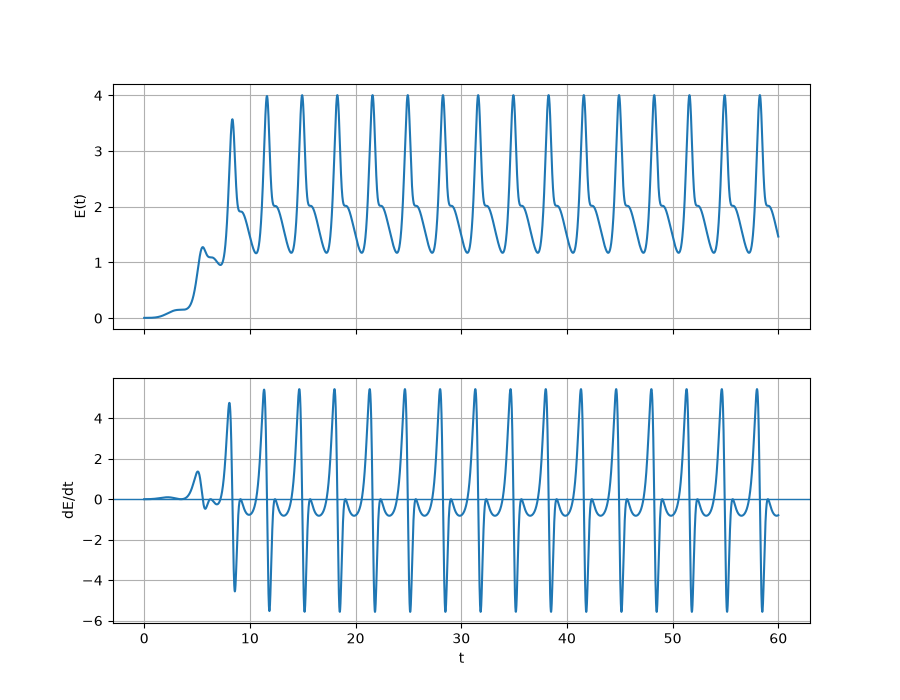

In [13]:
E_num = 0.5 * (x**2 + y**2)
E_dot_num = mu * (1 - x**2) * y**2

fig, ax = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax[0].plot(sol.t, E_num)
ax[0].set_ylabel("E(t)")
ax[0].grid()

ax[1].plot(sol.t, E_dot_num)
ax[1].axhline(0, linewidth=1)
ax[1].set_xlabel("t")
ax[1].set_ylabel("dE/dt")
ax[1].grid()

plt.show()

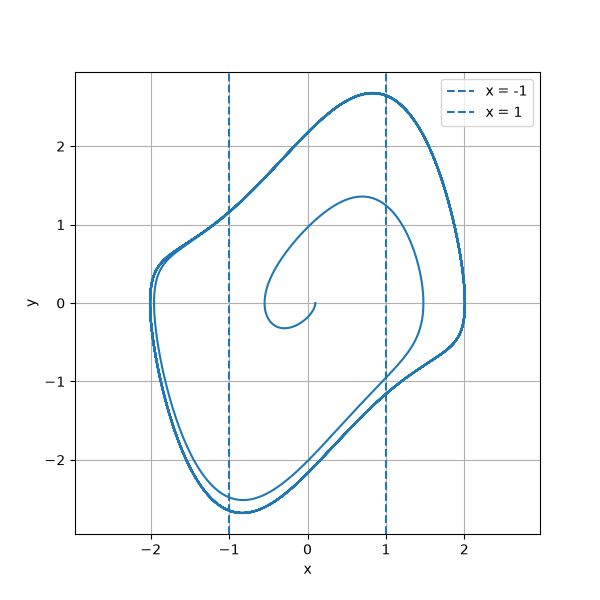

In [14]:
plt.figure(figsize=(6, 6))
plt.plot(x, y)
plt.axvline(-1, linestyle="--", label="x = -1")
plt.axvline(1, linestyle="--", label="x = 1")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

### Обсудите с преподавателем

Объясните:

1. почему малые колебания получают энергию;
2. почему при достаточно больших отклонениях энергия убывает;
3. как это связано с появлением устойчивого предельного цикла;
4. следует ли из $\dot E > 0$, что сама координата $x(t)$ обязательно растёт?

## 5. Баланс энергии за один период

На установившемся периодическом движении состояние после одного периода почти повторяется. Поэтому
$$
\Delta E
=
\int_{t_1}^{t_2}\dot E(t)\,dt
$$
должно быть близко к нулю.

Возьмём интервал между двумя последними максимумами $x(t)$.

In [15]:
i1, i2 = peaks[-2], peaks[-1]

t_cycle = t_ss[i1:i2 + 1]
x_cycle = x_ss[i1:i2 + 1]
y_cycle = y_ss[i1:i2 + 1]

E_dot_cycle = mu * (1 - x_cycle**2) * y_cycle**2

energy_balance = np.trapezoid(E_dot_cycle, t_cycle)

print(f"Интеграл dE/dt за один период ≈ {energy_balance:.6e}")
print(f"Длина выбранного периода ≈ {t_cycle[-1] - t_cycle[0]:.6f}")

Интеграл dE/dt за один период ≈ 7.983350e-07
Длина выбранного периода ≈ 6.660000


Почему интеграл получился не ровно нулём?

Назовите хотя бы две причины. И как вы думаете: был бы он близок к нулю на самом первом колебании?

## 6. Что меняется при изменении $\mu$

Теперь проведём один и тот же эксперимент для нескольких значений параметра.

Функция ниже автоматически:

- решает систему;
- отбрасывает начало траектории;
- оценивает амплитуду;
- оценивает период.

In [16]:
def cycle_stats(mu, t_end=160, t_cut=100):
    t_eval = np.linspace(0, t_end, 12001)

    sol_mu = solve_ivp(
        vdp,
        (0, t_end),
        [0.1, 0.0],
        t_eval=t_eval,
        args=(mu,),
        rtol=1e-8,
        atol=1e-10,
    )

    mask = sol_mu.t >= t_cut
    t = sol_mu.t[mask]
    x = sol_mu.y[0, mask]

    amplitude = (x.max() - x.min()) / 2

    peaks, _ = find_peaks(x, prominence=0.5)
    peak_times = t[peaks]
    period = np.diff(peak_times[-6:]).mean()

    return amplitude, period

Сначала сделайте прогноз для
$$
\mu=0.2,\;0.5,\;1,\;2,\;5.
$$

Как вы ожидаете, что будут меняться амплитуда и период? Запомните свой ответ и только потом запускайте расчёт.

In [17]:
mu_values = [0.2, 0.5, 1.0, 2.0, 5.0]

results = []

for mu_value in mu_values:
    A, T = cycle_stats(mu_value)
    results.append((mu_value, A, T))

for mu_value, A, T in results:
    print(f"mu={mu_value:>3}:  A≈{A:.5f},  T≈{T:.5f}")

mu=0.2:  A≈2.00041,  T≈6.29867
mu=0.5:  A≈2.00249,  T≈6.38133
mu=1.0:  A≈2.00862,  T≈6.66133
mu=2.0:  A≈2.01989,  T≈7.62933
mu=5.0:  A≈2.02151,  T≈11.61333


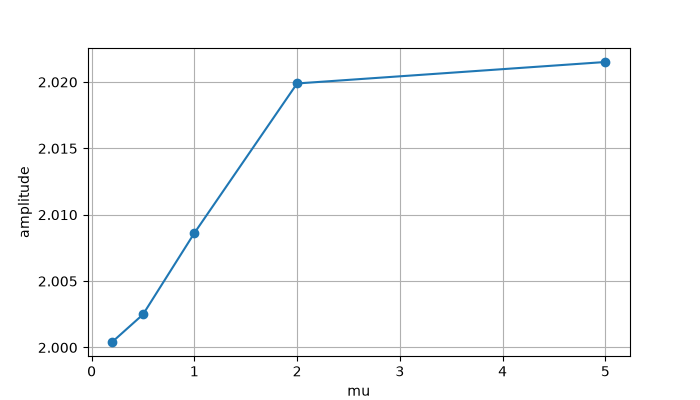

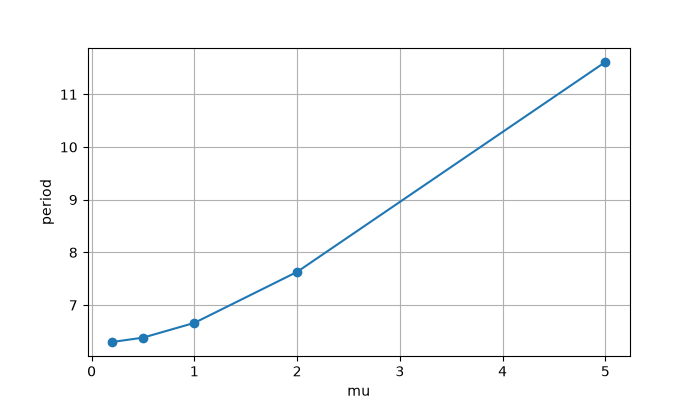

In [18]:
results_array = np.array(results)

plt.figure(figsize=(7, 4))
plt.plot(results_array[:, 0], results_array[:, 1], "o-")
plt.xlabel("mu")
plt.ylabel("amplitude")
plt.grid()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(results_array[:, 0], results_array[:, 2], "o-")
plt.xlabel("mu")
plt.ylabel("period")
plt.grid()
plt.show()

## 7. Как меняется сам предельный цикл

Графики $A(\mu)$ и $T(\mu)$ дают два числа для каждого значения параметра, но по ним не видно, как меняется **форма** цикла.

Построим установившиеся фазовые траектории на одном рисунке.

Перед запуском подумайте: при росте $\mu$ цикл должен просто равномерно увеличиваться или его форма может меняться сильнее, чем амплитуда?

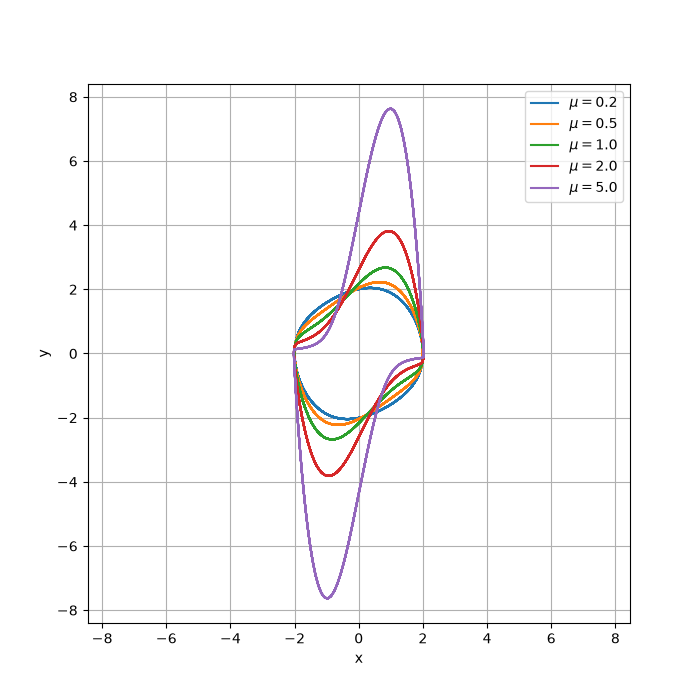

In [19]:
def settled_cycle(mu, t_end=200, t_cut=120):
    t_eval = np.linspace(0, t_end, 15001)

    sol_mu = solve_ivp(
        vdp,
        (0, t_end),
        [0.1, 0.0],
        t_eval=t_eval,
        args=(mu,),
        rtol=1e-8,
        atol=1e-10,
    )

    mask = sol_mu.t >= t_cut
    return sol_mu.y[0, mask], sol_mu.y[1, mask]


mu_for_phase_plot = [0.2, 0.5, 1.0, 2.0, 5.0]

plt.figure(figsize=(7, 7))

for mu_value in mu_for_phase_plot:
    x_cycle, y_cycle = settled_cycle(mu_value)
    plt.plot(x_cycle, y_cycle, label=fr"$\mu={mu_value}$")

plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

### Последняя проверка на паре

1. Добавьте в список значение `mu = 3.0` и перестройте рисунок.
2. Что с ростом $\mu$ меняется заметнее: максимальное значение $|x|$ или форма фазовой кривой?
3. Почему для построения цикла мы сначала отбрасываем большой начальный участок?
4. Объясните, зачем здесь понадобилась отдельная функция `settled_cycle`.

Если останется время, попробуйте заменить начальное условие `[0.1, 0.0]` на `[3.0, 0.0]`. Совпадёт ли установившийся цикл?

---

## Что сегодня использовали из Python

По ходу одной задачи нам понадобились:

- индексация NumPy-массивов;
- `shape` и булевы маски;
- `max`, `min`, `np.diff`;
- поиск пиков;
- функции;
- цикл по значениям параметра;
- SymPy для символического вычисления;
- Matplotlib для сравнения серии экспериментов.

Смысл всего этого — не в отдельных командах Python. Они позволяют перейти от одного рисунка к нормальному вычислительному исследованию модели.

# Домашняя работа

Продолжите этот notebook. Отдельную большую программу писать не нужно.

Все численные утверждения в выводах должны получаться из кода.

## 1. Амплитуда и период как функции $\mu$

Возьмите не менее **12 значений**
$$
\mu\in[0.2,5].
$$

Для каждого значения автоматически найдите:

- амплитуду $A(\mu)$;
- период $T(\mu)$.

Постройте графики
$$
A(\mu),\qquad T(\mu).
$$

После них напишите несколько предложений о том, что меняется с ростом $\mu$.

Не копируйте один и тот же расчёт 12 раз: используйте функцию и цикл.

## 2. Предельные циклы при разных $\mu$

На **одном фазовом рисунке** постройте установившиеся предельные циклы как минимум для
$$
\mu=0.2,\quad1,\quad3,\quad5.
$$

Используйте одинаковый масштаб по осям (`plt.axis("equal")`).

После рисунка коротко ответьте:

- что происходит с формой цикла при росте $\mu$;
- сильно ли при этом меняется диапазон значений $x$;
- чем этот рисунок дополняет графики $A(\mu)$ и $T(\mu)$.

## 3. Баланс энергии

Для
$$
\mu=0.5,\quad1,\quad3
$$
на одном из последних периодов вычислите
$$
I(\mu)=\int_{t_1}^{t_2}\dot E(t)\,dt.
$$

Объясните, почему ожидается $I(\mu)\approx 0$ и почему численно получается не ровно ноль.

## 4. Насколько результат зависит от точности solver'а

Для $\mu=3$ оцените период дважды:

1. `rtol=1e-5`, `atol=1e-7`;
2. `rtol=1e-9`, `atol=1e-11`.

Посчитайте относительное отличие:
$$
\frac{|T_1-T_2|}{|T_2|}.
$$

Достаточно ли первого расчёта, если нас интересует период с точностью примерно до двух знаков после запятой?

## Перед сдачей

- выполните `Restart Kernel → Run All`;
- проверьте, что notebook проходит сверху вниз без ошибок;
- подпишите оси и легенды;
- не дублируйте большие куски кода;
- после каждого эксперимента оставьте короткий вывод своими словами.